# Title: Customer Churn Prediction and Retention Analysis

## Problem Statement:
- Customer churn is the number of existing customers lost, for any reason at all, over a given period of time. It provides companies with an understanding of customer satisfaction and customer loyalty, and can identify potential changes in a company’s bottom line.[1]

- Churn affects B2B and B2C differently:
    - B2C customers do not need to get approval from a boss to start or finish a subscription, so they are more likely to impulse buy and impulse quit. Second, subscriptions are also likely to be cheaper, which means it’s easier to leave one service and start another. [1]
    - B2B companies either sell products or services. The former is often a one-time fee for an individual product. For those who sell software-as-a-service solutions, that is, SaaS companies, they can charge customers multiple times during the year for access to the service. The latter depends on their customers (subscribers) paying a monthly recurring revenue. [1]

## Calculating Churn Rate
- Churn Rate:
      Churn rate = (Lost customers/Total customers at the start of time period) x 100 [1]
- Monthly Recurring Revenue (MRR):
      MRR = Number of subscribers x average revenue per subscriber (ARPU) [1]
- Revenue Churn Rate:
      Revenue churn rate = (Revenue lost to churn/Total MRR in the time period) x 100 [1]


## Reference:
[1] : [IBM Customer Churn](https://www.ibm.com/think/topics/customer-churn)
[2] : [IBM Teleco Customer Churn](https://community.ibm.com/community/user/blogs/steven-macko/2019/07/11/telco-customer-churn-1113)


# Day-1
## Project Objective
The primary objective of this project is to analyze customer behavior patterns and predict whether a customer is likely to churn using machine learning techniques.

By identifying high-risk customers early, businesses can:

improve customer retention strategies,
reduce revenue loss,
increase customer lifetime value,
and make data-driven business decisions.

This project focuses on:

exploratory data analysis (EDA),
customer behavior analysis,
feature engineering,
churn prediction using classification models,
and business insights for customer retention.

## Business Problem
Customer acquisition is often more expensive than customer retention. Telecom companies face significant financial losses when customers discontinue their services.

The challenge is to identify customers who are likely to churn before they leave the service.

Using predictive analytics and machine learning, companies can:

proactively target at-risk customers,
optimize retention campaigns,
improve customer satisfaction,
and reduce churn-related revenue loss.

## Machine Learning Task
This project is a supervised machine learning classification problem where:

Input: Customer demographic, account, and service-related features
Output: Whether the customer churns or not

Target Variable:

Churn
Yes → Customer left the company
No → Customer stayed with the company

In [2]:
# Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

warnings.filterwarnings('ignore')

# Display settings
pd.set_option('display.max_columns', None)
sns.set_style("whitegrid")

print("Success: Libraries imported")

Success: Libraries imported


In [3]:
df = pd.read_csv('/kaggle/input/datasets/blastchar/telco-customer-churn/WA_Fn-UseC_-Telco-Customer-Churn.csv')
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [4]:
# Last 5 values
df.tail()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
7038,6840-RESVB,Male,0,Yes,Yes,24,Yes,Yes,DSL,Yes,No,Yes,Yes,Yes,Yes,One year,Yes,Mailed check,84.80,1990.5,No
7039,2234-XADUH,Female,0,Yes,Yes,72,Yes,Yes,Fiber optic,No,Yes,Yes,No,Yes,Yes,One year,Yes,Credit card (automatic),103.20,7362.9,No
7040,4801-JZAZL,Female,0,Yes,Yes,11,No,No phone service,DSL,Yes,No,No,No,No,No,Month-to-month,Yes,Electronic check,29.60,346.45,No
7041,8361-LTMKD,Male,1,Yes,No,4,Yes,Yes,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Mailed check,74.40,306.6,Yes
7042,3186-AJIEK,Male,0,No,No,66,Yes,No,Fiber optic,Yes,No,Yes,Yes,Yes,Yes,Two year,Yes,Bank transfer (automatic),105.65,6844.5,No


## Dataset Overview
### Key information
- Total Records: 7043
- Number of Features: 21
- Target variable: Churn
- Problem type: Binary Classification
### Feature Categories
- Demographic Information
- Account Information
- Service Usage Information
- Billing Information

In [5]:
# Dataset Shape
df.shape

(7043, 21)

In [6]:
# Columns
print("Columns in dataset")
for column_name in df.columns:
    print(column_name)

Columns in dataset
customerID
gender
SeniorCitizen
Partner
Dependents
tenure
PhoneService
MultipleLines
InternetService
OnlineSecurity
OnlineBackup
DeviceProtection
TechSupport
StreamingTV
StreamingMovies
Contract
PaperlessBilling
PaymentMethod
MonthlyCharges
TotalCharges
Churn


In [7]:
# Information of columns
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [8]:
# Numeric columns (statistical summary)
df.describe()

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


In [9]:
# Missing Values
missing_values = df.isnull().sum()
missing_values[missing_values > 0]

Series([], dtype: int64)

In [10]:
# Hidden missing values (check for TotalCharges)
print("Blank TotalCharges entries: ", (df['TotalCharges'] == ' ').sum())

Blank TotalCharges entries:  11


### Observation
- TotalCharges contains blank string values even though it should represent a numeric billing field
- This is a hidden missing-value issue, so the column will need cleaning before preprocessing and modeling

In [11]:
# Duplicate Rows
print("Duplicate Rows: ", df.duplicated().sum())

Duplicate Rows:  0


# Exploratory Data Analysis (EDA)

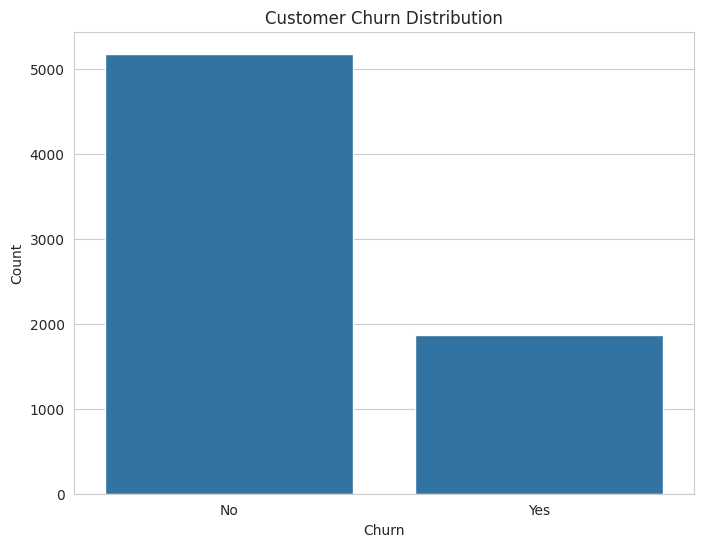

In [12]:
# Target Distribution: Churn
# Plot: Churn vs Count graph
plt.figure(figsize=(8,6))
sns.countplot(x="Churn", data=df)
plt.title("Customer Churn Distribution")
plt.xlabel("Churn")
plt.ylabel("Count")
plt.show()

### Important Obeservation:
- There is imbalance in dataset: more No churn then Yes
- Appropriate evaluation metrics and possibly resampling or class-weighted models
- Recall on churn class is important 

In [13]:
# Churn Percentage
churn_percentage = df["Churn"].value_counts(normalize=True) * 100
print(churn_percentage)

Churn
No     73.463013
Yes    26.536987
Name: proportion, dtype: float64


In [14]:
# Numerical vs Categorical features
numerical_features = df.select_dtypes(include=["int64", "float64"]).columns.tolist()
categorical_features = df.select_dtypes(include=['object']).columns.tolist()
print("Numerical Features: ", numerical_features)
print("Categorical Features: ", categorical_features)

Numerical Features:  ['SeniorCitizen', 'tenure', 'MonthlyCharges']
Categorical Features:  ['customerID', 'gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'TotalCharges', 'Churn']


### Customer Demographics

### Gender vs Churn

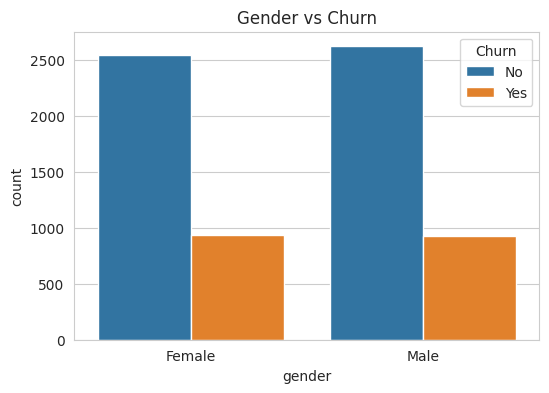

In [15]:
plt.figure(figsize=(6,4))
sns.countplot(x="gender", hue="Churn", data=df)
plt.title("Gender vs Churn")
plt.show()

### Observation
- Churn distribution appears similar across genders
- Gender alone may not be a strong predictor of churn (but it may interactwith other features)

### Senior Citizen vs Churn

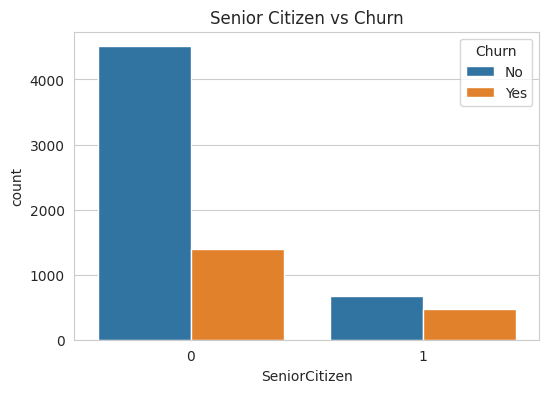

In [16]:
plt.figure(figsize=(6,4))
sns.countplot(x='SeniorCitizen', hue='Churn', data=df)
plt.title('Senior Citizen vs Churn')
plt.show()

### Observation
- Not senior citizen: 0, Yes senior citizen: 1
- Senior citizens appera to have a higher proportion of churn compared to non-senior customers
- Reason: Product fit, Pricing Sensitivity, or Service usability

### Contract Type vs Churn

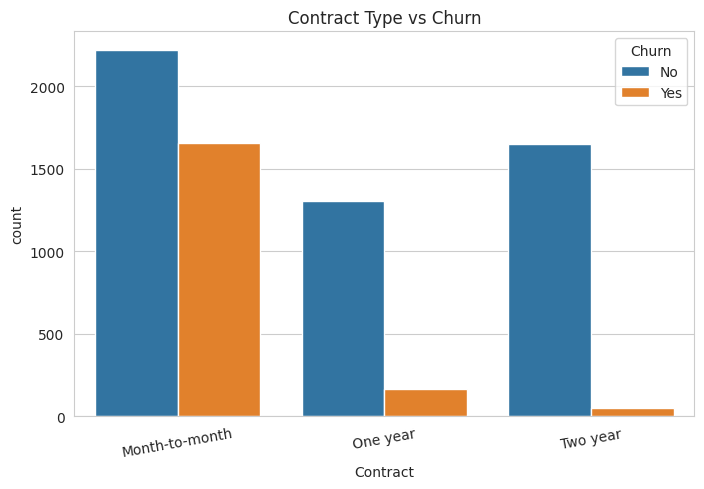

In [17]:
plt.figure(figsize=(8,5))
sns.countplot(x='Contract', hue='Churn', data=df)
plt.title("Contract Type vs Churn")
plt.xticks(rotation=10)
plt.show()

### Observation
- Count: Month-to-Month > Two-Year > One-Year
- Customers with Month-to-Month contracts have significantly higher churn rate
- Longer Contracts (in terms of year) show lower churn (suggests contract length increases retention)

In [18]:
# Churn percentage by contract type
contract_churn_pct = pd.crosstab(df['Contract'], df['Churn'], normalize='index') * 100
contract_churn_pct.round(2)

Churn,No,Yes
Contract,,
Month-to-month,57.29,42.71
One year,88.73,11.27
Two year,97.17,2.83


### Payment Method vs Churn

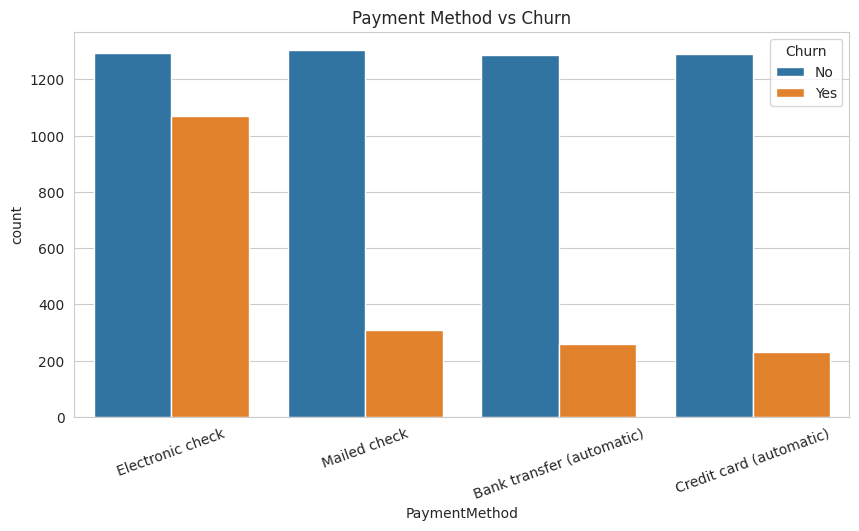

In [19]:
plt.figure(figsize=(10,5))
sns.countplot(x='PaymentMethod', hue='Churn', data=df)
plt.title("Payment Method vs Churn")
plt.xticks(rotation=20)
plt.show()

### Observation
- Electronic checks show higher churn proportions
- Possible indications: failed payments, billing friction or differences in customer segments

### Tenure Distribution

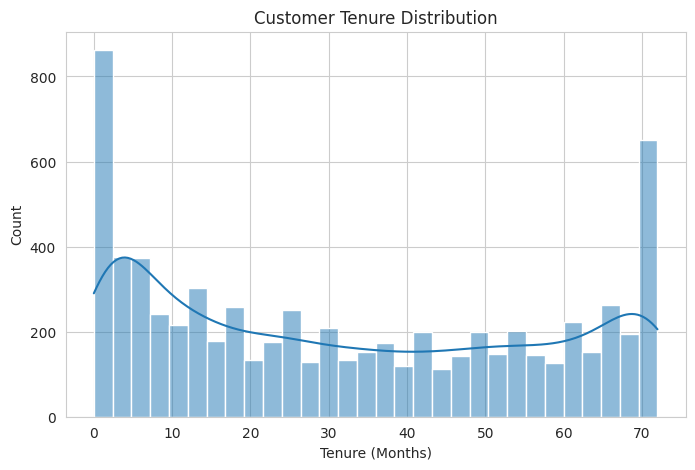

In [20]:
plt.figure(figsize=(8,5))
sns.histplot(df['tenure'], bins=30, kde=True)
plt.title("Customer Tenure Distribution")
plt.xlabel("Tenure (Months)")
plt.show()

### Observation
- Tenure distribution is skewed toward newer customers (shorter tenure).
- short-tenure customers are more likely to churn

### Monthly Charges vs Churn

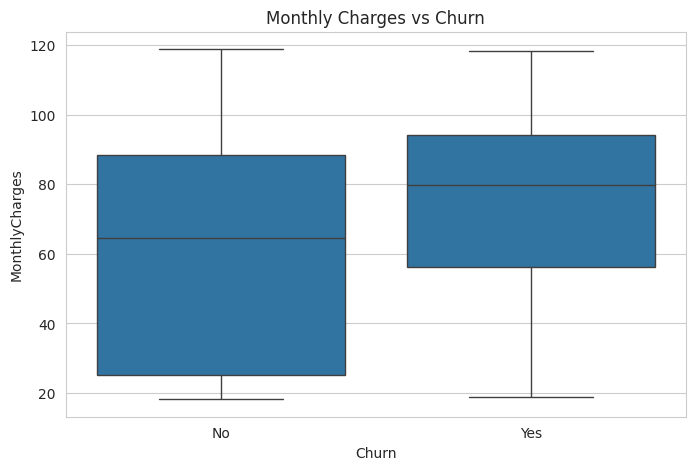

In [21]:
plt.figure(figsize=(8,5))
sns.boxplot(x='Churn', y='MonthlyCharges', data=df)
plt.title("Monthly Charges vs Churn")
plt.show()

### Observations
- Customers with highly monthly charges tend to churn more often

### Internet Service vs Churn

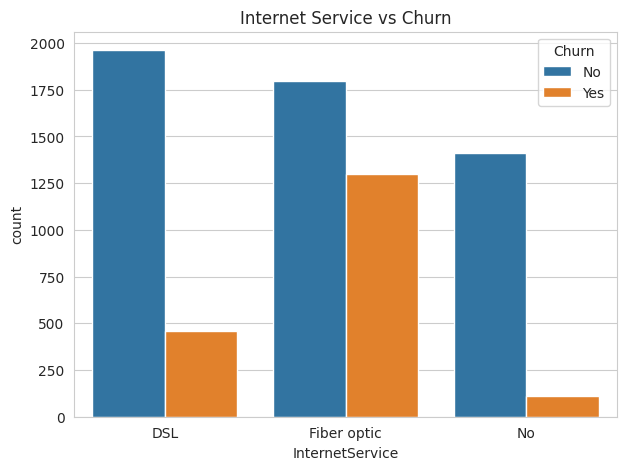

In [22]:
plt.figure(figsize=(7,5))
sns.countplot(x='InternetService', hue='Churn', data=df)
plt.title("Internet Service vs Churn")
plt.show()

### Observation
- Customers opting for fibre optics have higher churn rate as compared to DSL

### Tech Support vs Churn

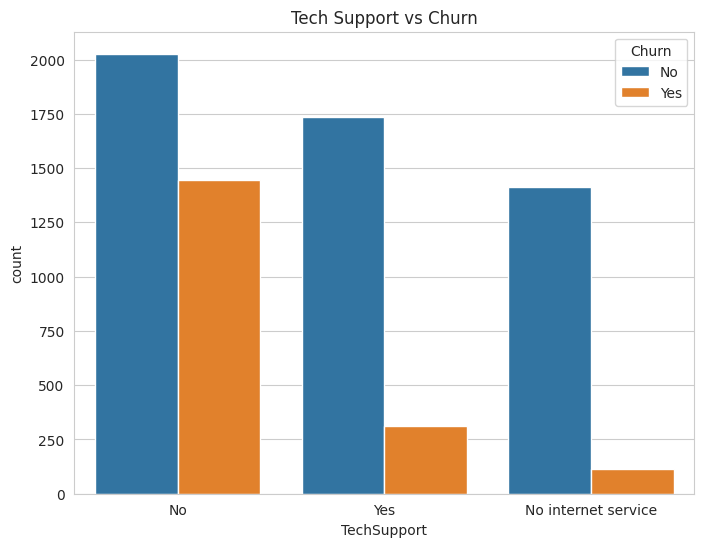

In [23]:
plt.figure(figsize=(8,6))
sns.countplot(x="TechSupport", hue="Churn", data=df)
plt.title("Tech Support vs Churn")
plt.show()

### Observation
- Customer with no tech support churn more often
- Support quality affects retention

### Tenure vs MonthlyCharges

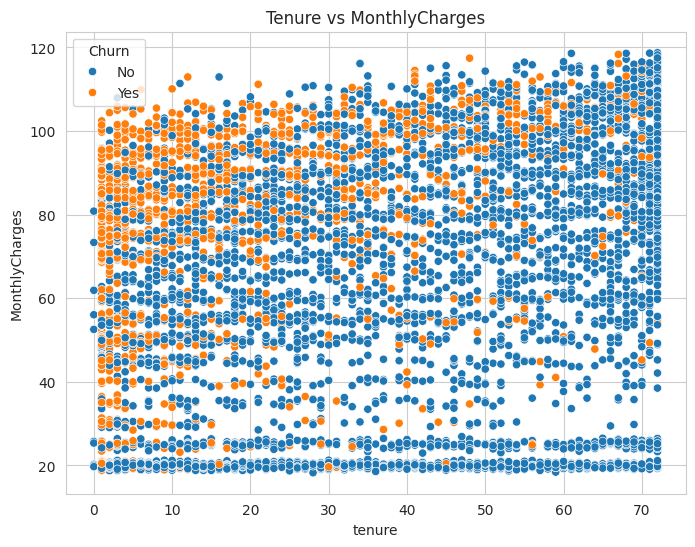

In [24]:
plt.figure(figsize=(8,6))
sns.scatterplot(x="tenure", y="MonthlyCharges", hue="Churn", data=df)
plt.title("Tenure vs MonthlyCharges")
plt.show()

### Observation
- As the monthly charges increase for a new customer, the churn rate is also on the higher side
- Long time customers have a very less chance to churn

## Day-1 Summary
- Contract (month-to-month) → higher churn; Electronic check & Fiber Internet → higher churn; Higher MonthlyCharges correlates with churn; Senior citizens show elevated churn.
- TotalCharges has blank-string entries (hidden missing values)
- Added percentage-based analysis (crosstabs), boxplot for MonthlyCharges, churn-by-contract proportions, and targeted observations for each plot.

# Day-2: Data Cleaning + Feature Engineering
## Objectives
- Cleaned Dataset
- Handle Hidden missing values
- encode target variable
- Identify features that are important
- Prepare data for ML model

### Copy of Dataset

In [25]:
df_cleaned = df.copy()
print("Success: Dataset copied")

Success: Dataset copied


### Handle Hidden missing values in TotalCharges

In [26]:
# 1. Replace space with NaN
df_cleaned['TotalCharges'] = df_cleaned['TotalCharges'].replace(' ', np.nan)

# 2. Convert NaN to numeric
df_cleaned['TotalCharges'] = pd.to_numeric(df_cleaned['TotalCharges'])

#3. Check the data type
df_cleaned['TotalCharges'].dtype

#4. Check missing values
df_cleaned['TotalCharges'].isnull().sum()

#5. Now as there are only 11 values (containing 0), we can drop the same
df_cleaned.dropna(inplace=True)

print("Success: Missing values dropped")

Success: Missing values dropped


In [27]:
df_cleaned['TotalCharges'].isnull().sum()

np.int64(0)

### Remove Customer ID
- Unique values
- Can introduce noise in future

In [28]:
df_cleaned.drop('customerID', axis=1, inplace=True)
print("Success: Customer ID dropped")

Success: Customer ID dropped


### Encode Target Variable
- Yes -> 1
- No -> 0

In [29]:
df_cleaned['Churn'] = df_cleaned['Churn'].map({
    'Yes' : 1,
    'No' : 0
})

df_cleaned['Churn'].head()

0    0
1    0
2    1
3    0
4    1
Name: Churn, dtype: int64

### Numerical and Categorical Features

In [30]:
numerical_features = df_cleaned.select_dtypes(
    include=['int64', 'float64']
).columns.tolist()

categorical_features = df_cleaned.select_dtypes(
    include=['object']
).columns.tolist()

print("Numerical Features: ", numerical_features)
print("Categoical Features: ", categorical_features)

Numerical Features:  ['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges', 'Churn']
Categoical Features:  ['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod']


### Unique values in categorical columns?
- Understand encoding needs
- Detect inconsistencies

In [31]:
for col in categorical_features:
    print(f"\nColumns: {col}")
    print(df_cleaned[col].unique())


Columns: gender
['Female' 'Male']

Columns: Partner
['Yes' 'No']

Columns: Dependents
['No' 'Yes']

Columns: PhoneService
['No' 'Yes']

Columns: MultipleLines
['No phone service' 'No' 'Yes']

Columns: InternetService
['DSL' 'Fiber optic' 'No']

Columns: OnlineSecurity
['No' 'Yes' 'No internet service']

Columns: OnlineBackup
['Yes' 'No' 'No internet service']

Columns: DeviceProtection
['No' 'Yes' 'No internet service']

Columns: TechSupport
['No' 'Yes' 'No internet service']

Columns: StreamingTV
['No' 'Yes' 'No internet service']

Columns: StreamingMovies
['No' 'Yes' 'No internet service']

Columns: Contract
['Month-to-month' 'One year' 'Two year']

Columns: PaperlessBilling
['Yes' 'No']

Columns: PaymentMethod
['Electronic check' 'Mailed check' 'Bank transfer (automatic)'
 'Credit card (automatic)']


### Binary Encoding (for yes/no features)

In [32]:
binary_columns = []

for col in categorical_features:
    if df_cleaned[col].nunique() == 2 and col != 'gender':
        binary_columns.append(col)

print(binary_columns)

['Partner', 'Dependents', 'PhoneService', 'PaperlessBilling']


In [33]:
for col in binary_columns:
    df_cleaned[col] = df_cleaned[col].map({
        'Yes' : 1,
        'No' : 0
    })

print("Success: Binary Encoding")

Success: Binary Encoding


### Note: We are not encoding gender in above cells (as it contains male and female)

### Encoding gender

In [34]:
df_cleaned['gender'] = df_cleaned['gender'].map({
    'Male' : 1,
    'Female' : 0
})

print("Success: Binary Encoding (Gender)")

Success: Binary Encoding (Gender)


### One-Hot Encoding (Remaining categorical features)

1. Check remaining object columns

In [35]:
remaining_categorical = df_cleaned.select_dtypes(
    include=['object']
).columns.tolist()

print(remaining_categorical)

['MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaymentMethod']


2. Apply One-Hot Encoding

In [36]:
df_encoded = pd.get_dummies(
    df_cleaned,
    columns = remaining_categorical,
    drop_first = True
)

print("Success: One-Hot Encoding")

Success: One-Hot Encoding


### Dataset check

In [37]:
df_encoded.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,PaperlessBilling,MonthlyCharges,TotalCharges,Churn,MultipleLines_No phone service,MultipleLines_Yes,InternetService_Fiber optic,InternetService_No,OnlineSecurity_No internet service,OnlineSecurity_Yes,OnlineBackup_No internet service,OnlineBackup_Yes,DeviceProtection_No internet service,DeviceProtection_Yes,TechSupport_No internet service,TechSupport_Yes,StreamingTV_No internet service,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,0,0,1,0,1,0,1,29.85,29.85,0,True,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,True,False
1,1,0,0,0,34,1,0,56.95,1889.50,0,False,False,False,False,False,True,False,False,False,True,False,False,False,False,False,False,True,False,False,False,True
2,1,0,0,0,2,1,1,53.85,108.15,1,False,False,False,False,False,True,False,True,False,False,False,False,False,False,False,False,False,False,False,False,True
3,1,0,0,0,45,0,0,42.30,1840.75,0,True,False,False,False,False,True,False,False,False,True,False,True,False,False,False,False,True,False,False,False,False
4,0,0,0,0,2,1,1,70.70,151.65,1,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False


### Converting boolean columns to 0/1

In [38]:
bool_columns = df_encoded.select_dtypes(include='bool').columns
df_encoded[bool_columns] = df_encoded[bool_columns].astype(int)
print("Boolean columns converted successfully!")

Boolean columns converted successfully!


In [39]:
df_encoded.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,PaperlessBilling,MonthlyCharges,TotalCharges,Churn,MultipleLines_No phone service,MultipleLines_Yes,InternetService_Fiber optic,InternetService_No,OnlineSecurity_No internet service,OnlineSecurity_Yes,OnlineBackup_No internet service,OnlineBackup_Yes,DeviceProtection_No internet service,DeviceProtection_Yes,TechSupport_No internet service,TechSupport_Yes,StreamingTV_No internet service,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,0,0,1,0,1,0,1,29.85,29.85,0,1,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,1,0
1,1,0,0,0,34,1,0,56.95,1889.50,0,0,0,0,0,0,1,0,0,0,1,0,0,0,0,0,0,1,0,0,0,1
2,1,0,0,0,2,1,1,53.85,108.15,1,0,0,0,0,0,1,0,1,0,0,0,0,0,0,0,0,0,0,0,0,1
3,1,0,0,0,45,0,0,42.30,1840.75,0,1,0,0,0,0,1,0,0,0,1,0,1,0,0,0,0,1,0,0,0,0
4,0,0,0,0,2,1,1,70.70,151.65,1,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0


In [40]:
df_encoded.isnull().sum()

gender                                   0
SeniorCitizen                            0
Partner                                  0
Dependents                               0
tenure                                   0
PhoneService                             0
PaperlessBilling                         0
MonthlyCharges                           0
TotalCharges                             0
Churn                                    0
MultipleLines_No phone service           0
MultipleLines_Yes                        0
InternetService_Fiber optic              0
InternetService_No                       0
OnlineSecurity_No internet service       0
OnlineSecurity_Yes                       0
OnlineBackup_No internet service         0
OnlineBackup_Yes                         0
DeviceProtection_No internet service     0
DeviceProtection_Yes                     0
TechSupport_No internet service          0
TechSupport_Yes                          0
StreamingTV_No internet service          0
StreamingTV

In [41]:
df_encoded.info()

<class 'pandas.core.frame.DataFrame'>
Index: 7032 entries, 0 to 7042
Data columns (total 31 columns):
 #   Column                                 Non-Null Count  Dtype  
---  ------                                 --------------  -----  
 0   gender                                 7032 non-null   int64  
 1   SeniorCitizen                          7032 non-null   int64  
 2   Partner                                7032 non-null   int64  
 3   Dependents                             7032 non-null   int64  
 4   tenure                                 7032 non-null   int64  
 5   PhoneService                           7032 non-null   int64  
 6   PaperlessBilling                       7032 non-null   int64  
 7   MonthlyCharges                         7032 non-null   float64
 8   TotalCharges                           7032 non-null   float64
 9   Churn                                  7032 non-null   int64  
 10  MultipleLines_No phone service         7032 non-null   int64  
 11  MultipleL

### Dataset shape after encoding

In [42]:
print("final Dataset shape: ", df_encoded.shape)

final Dataset shape:  (7032, 31)


### Correlation Heatmap

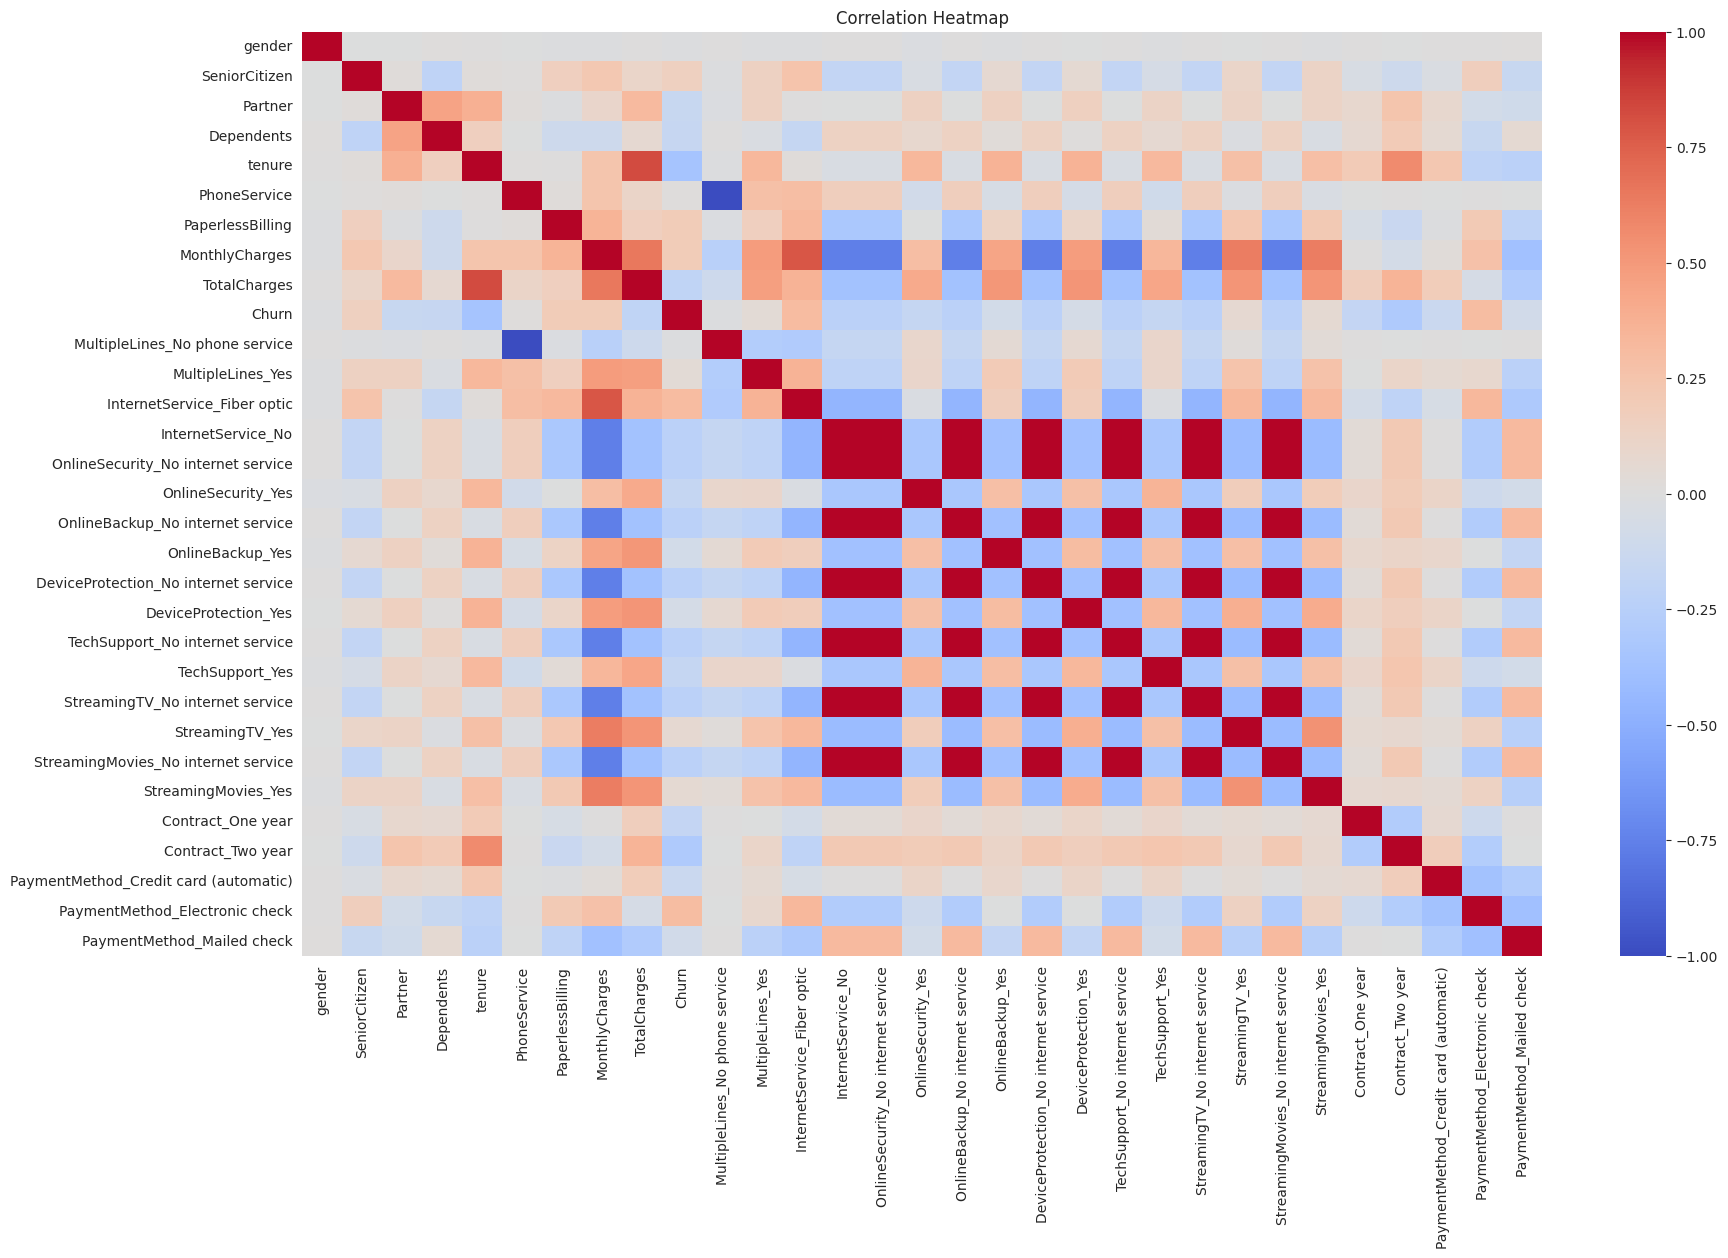

In [43]:
plt.figure(figsize=(20,12))
sns.heatmap(
    df_encoded.corr(),
    cmap='coolwarm'
)
plt.title("Correlation Heatmap")
plt.show()

### Correlation with Churn

In [44]:
churn_correlation = df_encoded.corr()['Churn'].sort_values(ascending=False)
print(churn_correlation)

Churn                                    1.000000
InternetService_Fiber optic              0.307463
PaymentMethod_Electronic check           0.301455
MonthlyCharges                           0.192858
PaperlessBilling                         0.191454
SeniorCitizen                            0.150541
StreamingTV_Yes                          0.063254
StreamingMovies_Yes                      0.060860
MultipleLines_Yes                        0.040033
PhoneService                             0.011691
gender                                  -0.008545
MultipleLines_No phone service          -0.011691
DeviceProtection_Yes                    -0.066193
OnlineBackup_Yes                        -0.082307
PaymentMethod_Mailed check              -0.090773
PaymentMethod_Credit card (automatic)   -0.134687
Partner                                 -0.149982
Dependents                              -0.163128
TechSupport_Yes                         -0.164716
OnlineSecurity_Yes                      -0.171270


### Top positives Correlations

In [45]:
top_positives = churn_correlation.head(10)
print(top_positives)

Churn                             1.000000
InternetService_Fiber optic       0.307463
PaymentMethod_Electronic check    0.301455
MonthlyCharges                    0.192858
PaperlessBilling                  0.191454
SeniorCitizen                     0.150541
StreamingTV_Yes                   0.063254
StreamingMovies_Yes               0.060860
MultipleLines_Yes                 0.040033
PhoneService                      0.011691
Name: Churn, dtype: float64


### Top negative correlations

In [46]:
top_negatives = churn_correlation.tail(10)
print(top_negatives)

TotalCharges                           -0.199484
InternetService_No                     -0.227578
StreamingTV_No internet service        -0.227578
OnlineSecurity_No internet service     -0.227578
OnlineBackup_No internet service       -0.227578
DeviceProtection_No internet service   -0.227578
StreamingMovies_No internet service    -0.227578
TechSupport_No internet service        -0.227578
Contract_Two year                      -0.301552
tenure                                 -0.354049
Name: Churn, dtype: float64


### Feature Engineering

Feature-1: Tenure Groups

In [47]:
df_encoded['tenure_group'] = pd.cut(
    df_encoded['tenure'],
    bins=[0,12,24,48,72],
    labels=[0,1,2,3]
)

In [48]:
df_encoded['tenure_group'] = df_encoded['tenure_group'].astype(int)

Feature-2: Average Charges Per Month

In [49]:
df_encoded['avg_charges_per_month'] = (
    df_encoded['TotalCharges'] / (df_encoded['tenure'] + 1)
)

Note: +1 in denominator is done to avoid division by zero case

Feature-3: Total Service Count

In [50]:
service_columns = [
    "PhoneService",
    "MultipleLines_Yes",
    "InternetService_Fiber optic",
    "OnlineSecurity_Yes",
    "OnlineBackup_Yes",
    "DeviceProtection_Yes",
    "TechSupport_Yes",
    "StreamingTV_Yes",
    "StreamingMovies_Yes"
]

existing_service_columns = [col for col in service_columns if col in df_encoded.columns]
missing_service_columns = [col for col in service_columns if col not in df_encoded.columns]

print("Using service columns:", existing_service_columns)
if missing_service_columns:
    print("Missing service columns:", missing_service_columns)

df_encoded["total_services"] = df_encoded[existing_service_columns].sum(axis=1)

Using service columns: ['PhoneService', 'MultipleLines_Yes', 'InternetService_Fiber optic', 'OnlineSecurity_Yes', 'OnlineBackup_Yes', 'DeviceProtection_Yes', 'TechSupport_Yes', 'StreamingTV_Yes', 'StreamingMovies_Yes']


Note: We can't take into columns like "InternetService_No" as a service becuase logically it is not a service. (Summing dummy columns directly may create wierd interpretations)

### Dataset Check

In [51]:
df_encoded.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,PaperlessBilling,MonthlyCharges,TotalCharges,Churn,MultipleLines_No phone service,MultipleLines_Yes,InternetService_Fiber optic,InternetService_No,OnlineSecurity_No internet service,OnlineSecurity_Yes,OnlineBackup_No internet service,OnlineBackup_Yes,DeviceProtection_No internet service,DeviceProtection_Yes,TechSupport_No internet service,TechSupport_Yes,StreamingTV_No internet service,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check,tenure_group,avg_charges_per_month,total_services
0,0,0,1,0,1,0,1,29.85,29.85,0,1,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,1,0,0,14.925000,1
1,1,0,0,0,34,1,0,56.95,1889.50,0,0,0,0,0,0,1,0,0,0,1,0,0,0,0,0,0,1,0,0,0,1,2,53.985714,3
2,1,0,0,0,2,1,1,53.85,108.15,1,0,0,0,0,0,1,0,1,0,0,0,0,0,0,0,0,0,0,0,0,1,0,36.050000,3
3,1,0,0,0,45,0,0,42.30,1840.75,0,1,0,0,0,0,1,0,0,0,1,0,1,0,0,0,0,1,0,0,0,0,2,40.016304,3
4,0,0,0,0,2,1,1,70.70,151.65,1,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,50.550000,2


### Correlation check

In [52]:
new_corr = df_encoded.corr()['Churn'].sort_values(ascending=False)
print(new_corr.head(15))

Churn                             1.000000
InternetService_Fiber optic       0.307463
PaymentMethod_Electronic check    0.301455
MonthlyCharges                    0.192858
PaperlessBilling                  0.191454
SeniorCitizen                     0.150541
avg_charges_per_month             0.070992
StreamingTV_Yes                   0.063254
StreamingMovies_Yes               0.060860
MultipleLines_Yes                 0.040033
PhoneService                      0.011691
total_services                    0.005927
gender                           -0.008545
MultipleLines_No phone service   -0.011691
DeviceProtection_Yes             -0.066193
Name: Churn, dtype: float64


### Feature Distribution Graphs

**Total Service Distribution**

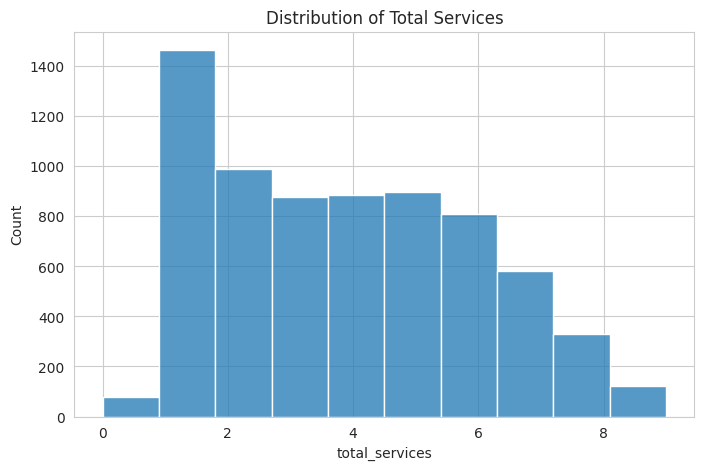

In [53]:
plt.figure(figsize=(8,5))
sns.histplot(df_encoded['total_services'], bins=10)
plt.title("Distribution of Total Services")
plt.show()

**Average Charges Distribution**

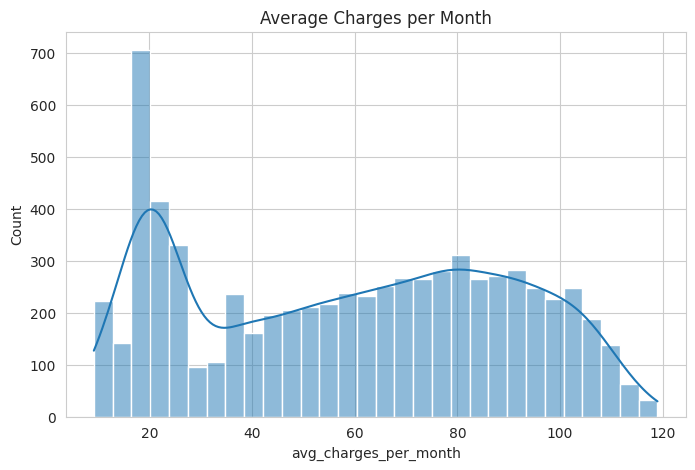

In [54]:
plt.figure(figsize=(8,5))
sns.histplot(df_encoded['avg_charges_per_month'], bins=30, kde=True)
plt.title("Average Charges per Month")
plt.show()

In [55]:
df_encoded.info()

<class 'pandas.core.frame.DataFrame'>
Index: 7032 entries, 0 to 7042
Data columns (total 34 columns):
 #   Column                                 Non-Null Count  Dtype  
---  ------                                 --------------  -----  
 0   gender                                 7032 non-null   int64  
 1   SeniorCitizen                          7032 non-null   int64  
 2   Partner                                7032 non-null   int64  
 3   Dependents                             7032 non-null   int64  
 4   tenure                                 7032 non-null   int64  
 5   PhoneService                           7032 non-null   int64  
 6   PaperlessBilling                       7032 non-null   int64  
 7   MonthlyCharges                         7032 non-null   float64
 8   TotalCharges                           7032 non-null   float64
 9   Churn                                  7032 non-null   int64  
 10  MultipleLines_No phone service         7032 non-null   int64  
 11  MultipleL

### Final Processed Dataset

In [56]:
df_encoded.to_csv("processed_customer_churn.csv", index=False)
print("Success: Processed dataset saved")

Success: Processed dataset saved


## Day-2 Summary
- Proper Preprocessing
- Hidden missing value handling
- Safe encoding
- Feature Engineering
- Correlation Analysis
- Dataset Validation
- Processed Dataset export

# Day-3: Baseline ML Models + Evaluation Metrics

## Objectives
- Train/Test split
- Scaling
- Logistic Regression
- Random Forest
- ROC-AUC
- Precision-Recall
- Confusion Matrix
- Classification Report

### Import ML Libraries

In [57]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, classification_report, confusion_matrix, ConfusionMatrixDisplay, RocCurveDisplay

print("Success: ML Libraries imported")

Success: ML Libraries imported


### Seperate Features and Target

In [58]:
# Features
X = df_encoded.drop('Churn', axis=1)

# Target
y = df_encoded['Churn']

print("Features shape: ", X.shape)
print("Target shape: ", y.shape)

Features shape:  (7032, 33)
Target shape:  (7032,)


### Train-Test Split
Here we would be using **stratify=y** because the dataset that we are using is imbalanced

In [59]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size = 0.2,
    random_state = 42,
    stratify = y
)

print("Training Set Shape: ", X_train.shape)
print("Testing Set Shape: ", X_test.shape)

Training Set Shape:  (5625, 33)
Testing Set Shape:  (1407, 33)


### Feature Scaling
For now we would be scaling full dataset

In [60]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
print("Success: Complete Feature scaling")

Success: Complete Feature scaling


Here we would only fit the train data because this prevents **Data Leakage**

### Evaluation Function

In [61]:
def evaluate_model(model, X_train, X_test, y_train, y_test):
    # Train model
    model.fit(X_train, y_train)

    # Prediction
    y_pred = model.predict(X_test)

    # Probabilities
    y_prob = model.predict_proba(X_test)[:,1]

    # Metrics
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    roc_auc = roc_auc_score(y_test, y_prob)

    # Results
    print(f"Accuracy: {accuracy:.4f}")
    print(f"Precision: {precision:.4f}")
    print(f"Recall: {recall:.4f}")
    print(f"F1 Score: {f1:.4f}")
    print(f"ROC-AUC: {roc_auc:.4f}")

    return {
        "Accuracy" : accuracy,
        "Precision" : precision,
        "Recall" : recall,
        "F1 Score" : f1,
        "ROC-AUC" : roc_auc
    }

### Logistic Regression

In [62]:
log_reg = LogisticRegression(
    max_iter = 1000,
    random_state = 42
)

log_reg_results = evaluate_model(
    log_reg,
    X_train_scaled,
    X_test_scaled,
    y_train,
    y_test
)

Accuracy: 0.7989
Precision: 0.6409
Recall: 0.5535
F1 Score: 0.5940
ROC-AUC: 0.8375


### Confusion Matrix (Logistic Regression)

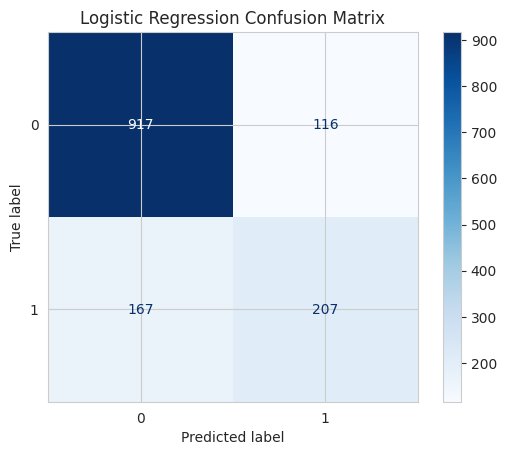

In [63]:
y_pred_log = log_reg.predict(X_test_scaled)

lr_cm = confusion_matrix(y_test, y_pred_log)

disp = ConfusionMatrixDisplay(confusion_matrix = lr_cm)

disp.plot(cmap='Blues')
plt.title("Logistic Regression Confusion Matrix")
plt.show()

### ROC Curve (Logistic Regression)

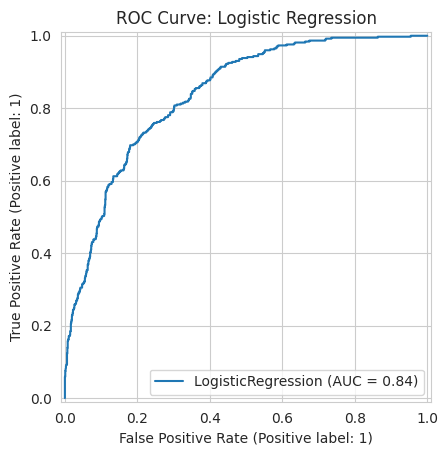

In [64]:
RocCurveDisplay.from_estimator(
    log_reg,
    X_test_scaled,
    y_test
)

plt.title("ROC Curve: Logistic Regression")

plt.show()

### Logistic Regression Evaluation
**Accuracy** : 79.89
**Precision** : 64.09
**Recall** : 55.35
**F1** : 59.40
**ROC-AUC** : 83.75
**AUC** : 84

### Decision Tree Classifier

In [65]:
decision_tree = DecisionTreeClassifier(
    random_state = 42,
    max_depth = 5
)

decision_tree_results = evaluate_model(
    decision_tree,
    X_train,
    X_test,
    y_train,
    y_test
)

Accuracy: 0.7783
Precision: 0.5807
Recall: 0.5963
F1 Score: 0.5884
ROC-AUC: 0.8195


Note: Here as trees do not require scaling, so we would be using **X_train** instead of **X_train_scaled**

### Confusion Matrix (Decision Tree)

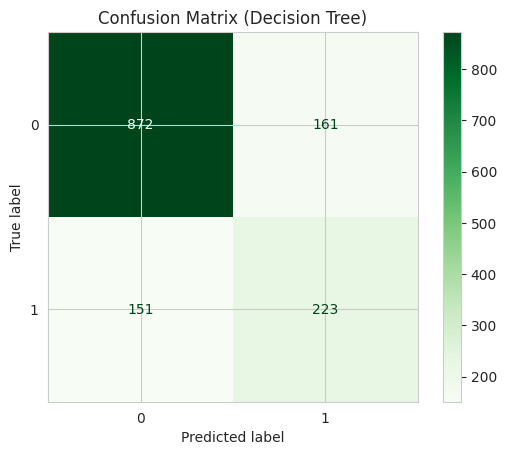

In [66]:
y_pred_dec = decision_tree.predict(X_test)

dt_cm = confusion_matrix(y_test, y_pred_dec)

dt_disp = ConfusionMatrixDisplay(confusion_matrix = dt_cm)

dt_disp.plot(cmap="Greens")

plt.title("Confusion Matrix (Decision Tree)")

plt.show()

### ROC Curve (Decision Tree Classifier)

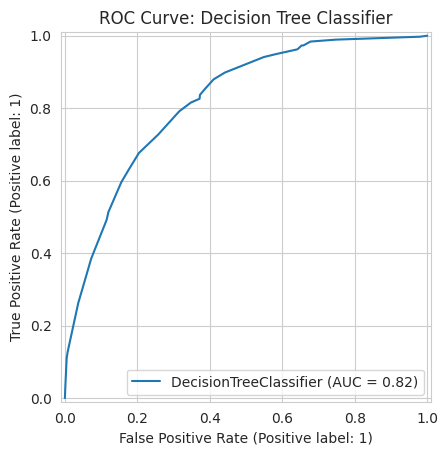

In [67]:
RocCurveDisplay.from_estimator(
    decision_tree,
    X_test,
    y_test
)

plt.title("ROC Curve: Decision Tree Classifier")

plt.show()

### Decision Tree Evaluation
**Accuracy** : 77.83
**Precision** : 58.07
**Recall** : 59.63
**F1** : 58.84
**ROC-AUC** : 81.95
**AUC** : 82

### Random Forest

In [68]:
random_forest = RandomForestClassifier(
    n_estimators = 200,
    random_state = 42,
    max_depth = 8
)

random_forest_results = evaluate_model(
    random_forest,
    X_train,
    X_test,
    y_train,
    y_test
)

Accuracy: 0.7889
Precision: 0.6370
Recall: 0.4786
F1 Score: 0.5466
ROC-AUC: 0.8364


### Confusion Matrix (Random Forest)

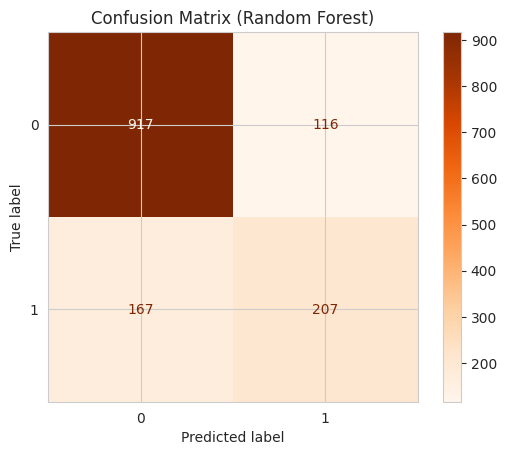

In [69]:
y_pred_rf = random_forest.predict(X_test)

rf_cm = confusion_matrix(y_test, y_pred_rf)

rf_disp = ConfusionMatrixDisplay(confusion_matrix = rf_cm)

disp.plot(cmap = "Oranges")

plt.title("Confusion Matrix (Random Forest)")

plt.show()

### ROC Curve (Random Forest)

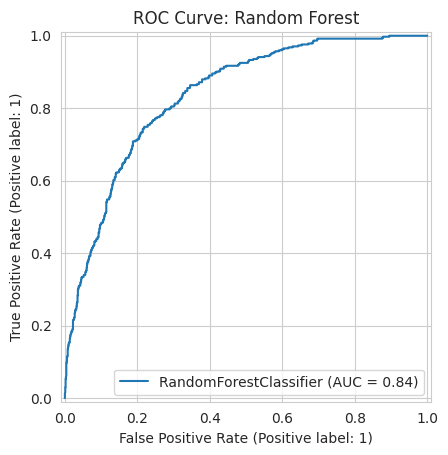

In [70]:
RocCurveDisplay.from_estimator(
    random_forest,
    X_test,
    y_test
)

plt.title("ROC Curve: Random Forest")

plt.show()

### Random Forest Evaluation
**Accuracy** : 78.89
**Precision** : 63.70
**Recall** : 47.86
**F1** : 54.66
**ROC-AUC** : 83.64
**AUC** : 84

### Compare Models

In [71]:
results_df = pd.DataFrame({
    "Logistic Regression" : log_reg_results,
    "Decision Tree" : decision_tree_results,
    "Random Forest" : random_forest_results
})

results_df

,Logistic Regression,Decision Tree,Random Forest
Accuracy,0.798863,0.778252,0.788913
Precision,0.640867,0.580729,0.637011
Recall,0.553476,0.596257,0.478610
F1 Score,0.593974,0.588391,0.546565
ROC-AUC,0.837523,0.819510,0.836376


### Visualized version of results

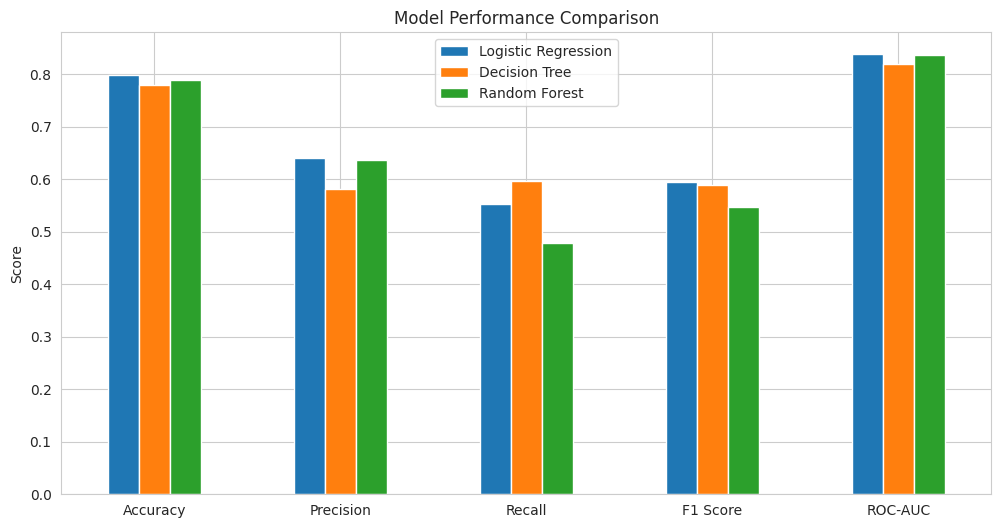

In [72]:
results_df.plot(
    kind='bar',
    figsize=(12,6)
)

plt.title("Model Performance Comparison")

plt.ylabel("Score")
plt.xticks(rotation=0)

plt.show()

### Feature Importance

**Random Forest**

In [73]:
feature_importance = pd.DataFrame({
    "Feature" : X.columns,
    "Importance" : random_forest.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

feature_importance.head(15)

,Feature,Importance
4,tenure,0.153223
8,TotalCharges,0.109416
30,tenure_group,0.097041
7,MonthlyCharges,0.082881
11,InternetService_Fiber optic,0.075813
31,avg_charges_per_month,0.071622
26,Contract_Two year,0.063846
28,PaymentMethod_Electronic check,0.055759
25,Contract_One year,0.029446
14,OnlineSecurity_Yes,0.026467


In [74]:
feature_importance.tail(10)

,Feature,Importance
1,SeniorCitizen,0.008834
0,gender,0.007105
2,Partner,0.006872
22,StreamingTV_Yes,0.006721
24,StreamingMovies_Yes,0.006437
29,PaymentMethod_Mailed check,0.005474
27,PaymentMethod_Credit card (automatic),0.005108
18,DeviceProtection_Yes,0.004647
9,MultipleLines_No phone service,0.002641
5,PhoneService,0.002615


**Visualize Top Features**

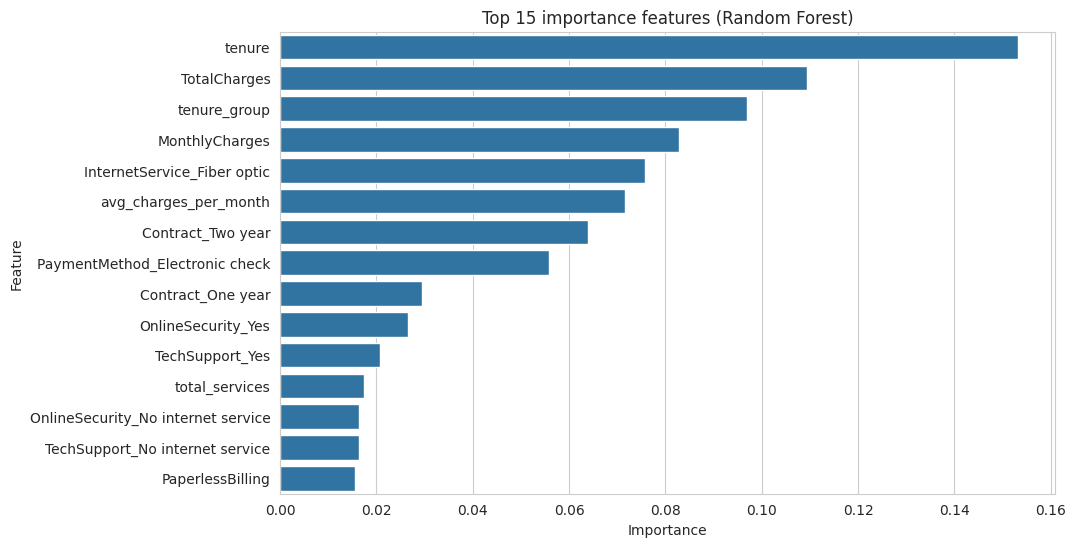

In [75]:
plt.figure(figsize=(10,6))

sns.barplot(
    x='Importance',
    y='Feature',
    data=feature_importance.head(15)
)

plt.title("Top 15 importance features (Random Forest)")

plt.show()

**Logistic Regression**

In [76]:
feature_importance_log_reg = pd.DataFrame({
    'Feature' : X.columns,
    'Coefficient' : log_reg.coef_[0]
})

feature_importance_log_reg = feature_importance_log_reg.sort_values(
    by='Coefficient',
    ascending=False
)

feature_importance_log_reg.head(15)

,Feature,Coefficient
11,InternetService_Fiber optic,0.882403
8,TotalCharges,0.559586
32,total_services,0.320498
22,StreamingTV_Yes,0.288110
24,StreamingMovies_Yes,0.282552
10,MultipleLines_Yes,0.232371
28,PaymentMethod_Electronic check,0.160624
6,PaperlessBilling,0.139965
1,SeniorCitizen,0.071014
18,DeviceProtection_Yes,0.065093


In [77]:
feature_importance_log_reg.tail(10)

,Feature,Coefficient
21,StreamingTV_No internet service,-0.103095
17,DeviceProtection_No internet service,-0.103095
20,TechSupport_Yes,-0.112179
30,tenure_group,-0.116360
14,OnlineSecurity_Yes,-0.137185
25,Contract_One year,-0.337130
7,MonthlyCharges,-0.337782
26,Contract_Two year,-0.714060
4,tenure,-0.863667
31,avg_charges_per_month,-1.192831


**Visualize Top Coefficients**

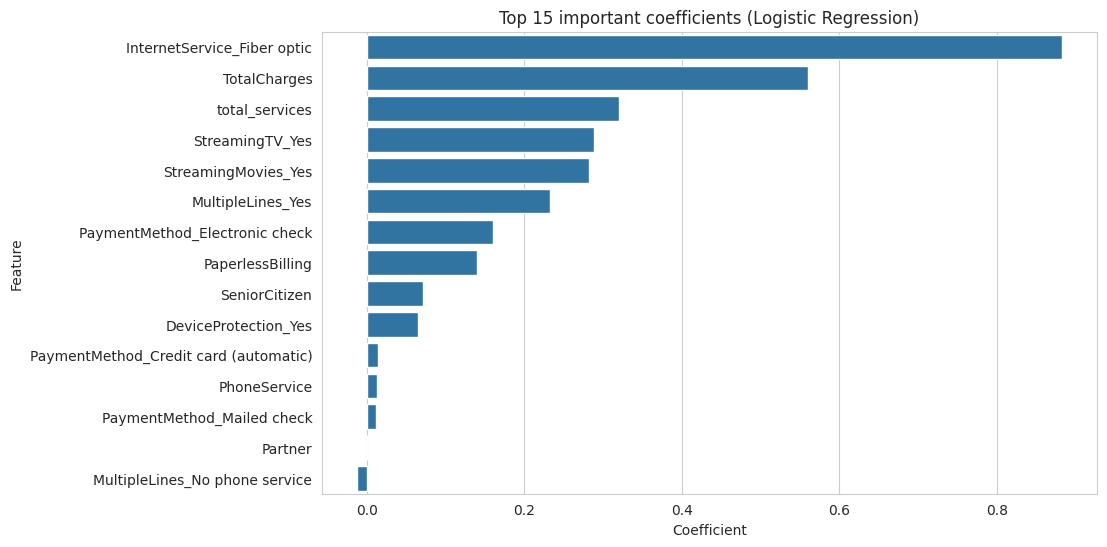

In [78]:
plt.figure(figsize=(10,6))

sns.barplot(
    x="Coefficient",
    y="Feature",
    data=feature_importance_log_reg.head(15)
)

plt.title("Top 15 important coefficients (Logistic Regression)")

plt.show()

**Decision Tree**

In [79]:
feature_importance_decision_tree = pd.DataFrame({
    'Feature' : X.columns,
    'Importance' : decision_tree.feature_importances_
})

feature_importance_decision_tree = feature_importance_decision_tree.sort_values(
    by='Importance',
    ascending=False
)

feature_importance_decision_tree.head(15)

,Feature,Importance
4,tenure,0.441283
11,InternetService_Fiber optic,0.338826
8,TotalCharges,0.033886
28,PaymentMethod_Electronic check,0.026809
23,StreamingMovies_No internet service,0.026778
7,MonthlyCharges,0.025198
26,Contract_Two year,0.019312
19,TechSupport_No internet service,0.015402
14,OnlineSecurity_Yes,0.015138
20,TechSupport_Yes,0.012159


**Visualize Top Features**

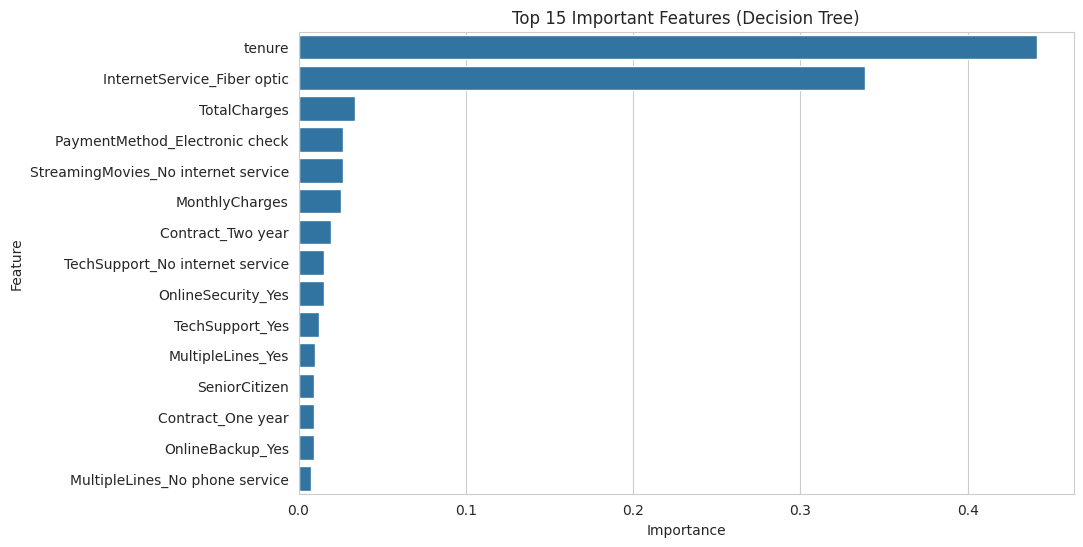

In [80]:
plt.figure(figsize=(10,6))

sns.barplot(
    x='Importance',
    y='Feature',
    data=feature_importance_decision_tree.head(15)
)

plt.title("Top 15 Important Features (Decision Tree)")

plt.show()

### Classification Report

**Random Forest**

In [81]:
print(classification_report(y_test, random_forest.predict(X_test)))

              precision    recall  f1-score   support

           0       0.83      0.90      0.86      1033
           1       0.64      0.48      0.55       374

    accuracy                           0.79      1407
   macro avg       0.73      0.69      0.70      1407
weighted avg       0.78      0.79      0.78      1407



**Logistic Regression**

In [82]:
print(classification_report(y_test, log_reg.predict(X_test_scaled)))

              precision    recall  f1-score   support

           0       0.85      0.89      0.87      1033
           1       0.64      0.55      0.59       374

    accuracy                           0.80      1407
   macro avg       0.74      0.72      0.73      1407
weighted avg       0.79      0.80      0.79      1407



**Decision Tree**

In [83]:
print(classification_report(y_test, decision_tree.predict(X_test)))

              precision    recall  f1-score   support

           0       0.85      0.84      0.85      1033
           1       0.58      0.60      0.59       374

    accuracy                           0.78      1407
   macro avg       0.72      0.72      0.72      1407
weighted avg       0.78      0.78      0.78      1407



## Observations

### Model Performance Comparison
3 Baseline Machine Leanring Models used for evaluation of Customer churn
- Logistic Regression
- Decision Tree
- Random Forest

Among them, **Logistic Regression** was the standout model with
- Highest Accuracy score
- Highest F1-score
- Higest ROC-AUC score

This indicates that the customer churn dataset exhibits relatively structured and linearly separable patterns, allowing Logistic Regression to generalize effectively.

Although ensemble models like Random Forest are often expected to outperform simpler models, this is not always guaranteed. In structured tabular datasets with strong predictive features, simpler linear models can perform competitively or even better.

### Precision vs Recall Tradeoff
**Logistic Regression**
- Better overall balance between precision and recall.
- Lower recall than Decision Tree but higher precision.

**Decision Tree**
- Highest recall among the three models.
- Captures more actual churners.
- However, it also produces more false positives.

**Random Forest**
- Strong ROC-AUC score.
- Higher precision compared to Decision Tree.
- Lower recall, meaning more actual churners are missed.

### Why Recall is important in Customer Churn
Recall is one of the most critical evaluation metrics.

Recall measures:

- Out of all customers who actually churned, how many were correctly identified?

In real business scenarios:

- False Negatives are expensive.
- A False Negative occurs when:
    - the model predicts that a customer will stay, but the customer actually churns.

This leads to:
customer loss, revenue loss, increased acquisition costs, and reduced customer lifetime value.

### Why ROC-AUC matters?
ROC-AUC measures the model’s ability to distinguish between churn and non-churn customers across multiple classification thresholds.

A higher ROC-AUC score indicates:

- stronger ranking capability,
- better class separation,
- and more reliable probability predictions.

All three models achieved relatively strong ROC-AUC scores (~0.82–0.84), indicating that the preprocessing and feature engineering pipeline successfully captured meaningful customer behavior patterns.

## Day-3 Summary
- Train/Test split
- Scaling
- Logistic Regression
- Random Forest
- ROC-AUC
- Precision-Recall
- Confusion Matrix
- Classification Report

# Day-4: Advanced Models + Hyperparameter Tuning + Kaggle Submission Optimization

## Observations
- XGBoost/LightGBM/CatBoost
- GridSearchCV
- RandomizedSearchCV
- threshold tuning
- leaderboard optimization
- model improvement

### Import Libraries

In [85]:
# Cross Validation
from sklearn.model_selection import cross_val_score, GridSearchCV, RandomizedSearchCV

# Models
from catboost import CatBoostClassifier
from lightgbm import LGBMClassifier
from xgboost import XGBClassifier

import joblib

print("Success: Libraries imported")

Success: Libraries imported


### XGBoost

In [86]:
xgb_model = XGBClassifier(
    n_estimators=200,
    max_depth=6,
    learning_rate=0.05,
    random_state=42,
    eval_metric='logloss'
)

xgb_results = evaluate_model(
    xgb_model,
    X_train,
    X_test,
    y_train,
    y_test
)

Accuracy: 0.7918
Precision: 0.6246
Recall: 0.5428
F1 Score: 0.5808
ROC-AUC: 0.8310


### XGBoost Evaluation:
**Accuracy** : 79.18
**Precision** : 62.46
**Recall** : 54.28
**F1** : 58.08
**ROC-AUC** : 83.10

### LightGBM

In [87]:
lgbm_model = LGBMClassifier(
    n_estimators=200,
    max_depth=6,
    learning_rate=0.05,
    random_state=42
)

lgbm_results = evaluate_model(
    lgbm_model,
    X_train,
    X_test,
    y_train,
    y_test
)

[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Number of positive: 1495, number of negative: 4130
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.002191 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 906
[LightGBM] [Info] Number of data points in the train set: 5625, number of used features: 33
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.265778 -> initscore=-1.016151
[LightGBM] [Info] Start training from score -1.016151
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best ga

### LightGBM Evaluation
**Accuracy** : 79.25
**Precision** : 62.65
**Recall** : 54.28
**F1** : 58.17
**ROC-AUC** : 83.53

### CatBoost

In [89]:
catboost_model = CatBoostClassifier(
    iterations=200,
    depth=6,
    learning_rate=0.05,
    verbose=0,
    random_state=42
)

catboost_results = evaluate_model(
    catboost_model,
    X_train,
    X_test,
    y_train,
    y_test
)

Accuracy: 0.7903
Precision: 0.6312
Recall: 0.5080
F1 Score: 0.5630
ROC-AUC: 0.8364


### Catboost Evaluation
**Accuracy** : 79.03
**Precision** : 63.12
**Recall** : 50.80
**F1** : 56.30
**ROC-AUC** : 83.64

### Compare Advanced models

In [90]:
advanced_results = pd.DataFrame({
    'XGBoost' : xgb_results,
    'lightGBM' : lgbm_results,
    'CatBoost' : catboost_results
}).T

advanced_results

,Accuracy,Precision,Recall,F1 Score,ROC-AUC
XGBoost,0.791756,0.624615,0.542781,0.580830,0.831016
lightGBM,0.792466,0.626543,0.542781,0.581662,0.835340
CatBoost,0.790334,0.631229,0.508021,0.562963,0.836387


### Comparison Plot

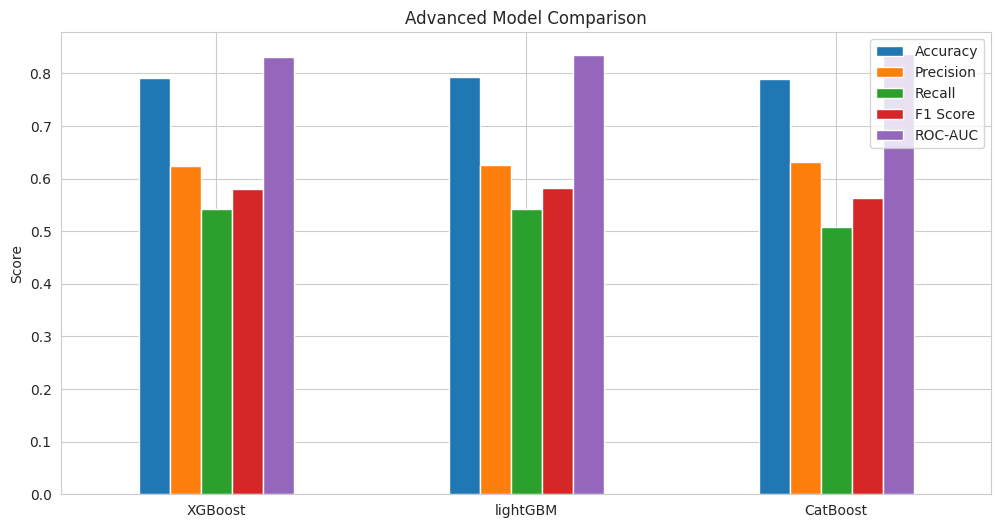

In [91]:
advanced_results.plot(
    kind='bar',
    figsize=(12,6)
)

plt.title("Advanced Model Comparison")
plt.ylabel("Score")
plt.xticks(rotation=0)

plt.show()

### Compare All Models

In [93]:
all_results = pd.DataFrame({
    'Logistic Regression' : log_reg_results,
    'Decision Tree' : decision_tree_results,
    'Random Forest' : random_forest_results,
    'XGBoost' : xgb_results,
    'LightGBM' : lgbm_results,
    'CatBoost' : catboost_results
}).T

all_results

,Accuracy,Precision,Recall,F1 Score,ROC-AUC
Logistic Regression,0.798863,0.640867,0.553476,0.593974,0.837523
Decision Tree,0.778252,0.580729,0.596257,0.588391,0.819510
Random Forest,0.788913,0.637011,0.478610,0.546565,0.836376
XGBoost,0.791756,0.624615,0.542781,0.580830,0.831016
LightGBM,0.792466,0.626543,0.542781,0.581662,0.835340
CatBoost,0.790334,0.631229,0.508021,0.562963,0.836387


### All Model Comparison Plot

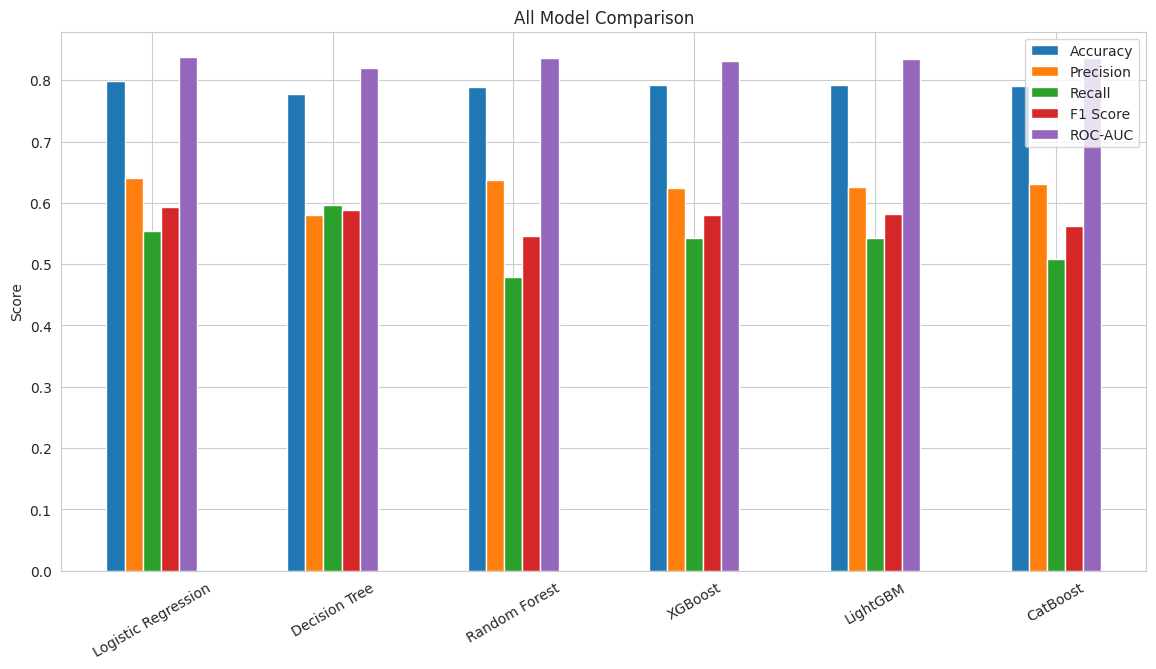

In [94]:
all_results.plot(
    kind='bar',
    figsize=(14,7)
)

plt.title("All Model Comparison")
plt.ylabel("Score")
plt.xticks(rotation=30)

plt.show()